In [1]:
import quanguru as qg
import numpy as np
import matplotlib.pyplot as plt

# 21 - Simultaneous Simulation JC and Rabi models and 1st and 2nd order DQSs of Rabi


The Rabi Hamiltonian (also called the quantum Rabi model) is written as: $H_{JC} = \hbar\omega_{c} a^{\dagger}a + \frac{1}{2}\hbar\omega_{q}\sigma_{z} + \hbar g(a^{\dagger}+ a)(\sigma_{+} + \sigma_{-})$


The Jaynes-Cummings model descibed by:
$H_{JC} = \hbar\omega_{c} a^{\dagger}a + \frac{1}{2}\hbar\omega_{q}\sigma_{z} + \hbar g(a^{\dagger}\sigma_{-} + a\sigma_{+})$

The JC model is derived from the Rabi model by applying the Rotating Wave Approximation (RWA), which drops the counter-rotating (anti-resonant) terms 
$ a^{\dagger} \sigma_{+}$ and $a \sigma_{-}$  under the assumption that $g ≪ \omega_{c}, \omega_{q}$.

In this tutorial we will demonstrate how to simultaneously simulate both quantum systems to compare the two models.
​

In [2]:
# parameters for the Hamiltonian
qubitFreq = 1
cavityFreq = 1
couplingFreq = 0.1 
cavityDim = 5

# parameters for the evolution
totalTime = 2*(np.pi/couplingFreq)
timeStep = 0.05

Unlike Tutorial 20 where we used the built-in `.JC(g)` method, here we manually construct the Jaynes-Cummings interaction using `QTerm` and `createTerm`.

This explicitly constructs: $H_{JCint} = \hbar g(a\sigma_+ + a^\dagger\sigma_-)$

The Rabi coupling uses the built-in method `.Rabi(g)` for comparison.


In [3]:
JCSystem = qg.Qubit(frequency=qubitFreq, alias='QubJC') + qg.Cavity(dimension=cavityDim, frequency=cavityFreq, alias='CavJC')

RabiSystem = JCSystem.copy()

JCCoupling = qg.QTerm(qSystem=JCSystem,
                      subSys=[
                        JCSystem.createTerm(qSystem=["CavJC", "QubJC"], operator=[qg.destroy, qg.sigmap]),
                        JCSystem.createTerm(qSystem=["QubJC", "CavJC"], operator=[qg.sigmam, qg.create])
                        ],
                      frequency=couplingFreq,
                      alias='jc')

RabiCoupling = RabiSystem.Rabi(couplingFreq)

## Digital Quantum Simulation (DQS) via Trotterization

The quantum Rabi model cannot be efficiently simulated using only JC-type interactions directly. However, we can **digitally synthesize** the Rabi dynamics using Trotter decomposition.

### Decomposing the Rabi Hamiltonian

The full Rabi Hamiltonian is comprised of:
$$H_{Rabi} = H_0 + H_{JC} + H_{AJC}$$

where:
- $H_0 = \omega_c a^\dagger a + \frac{\omega_q}{2}\sigma_z$ (free evolution)
- $H_{JC} = g(a^\dagger\sigma_- + a\sigma_+)$ (Jaynes-Cummings, energy-conserving)
- $H_{AJC} = g(a^\dagger\sigma_+ + a\sigma_-)$ (anti-Jaynes-Cummings, counter-rotating)

### Implementing the Anti-JC Term

The anti-JC term can be constructed from JC by a **qubit basis flip**:
$$U_{AJC}(\tau) = \sigma_x \cdot U_{JC}(\tau) \cdot \sigma_x$$

where $\sigma_x$ is a $\pi$-rotation about the x-axis (bit flip).

$\sigma_x$ transforms $\sigma_\pm \leftrightarrow \sigma_\mp$, so:
$$\sigma_x (a^\dagger\sigma_- + a\sigma_+) \sigma_x = a^\dagger\sigma_+ + a\sigma_-$$

We can implement this with `bitFlip = qg.SpinRotation(system="QubJC", angle=np.pi, rotationAxis='x')`.

To create the `AJCStep` we create a `qProtocol` object with a full `JCStep` in between two `bitFlip`s.
```
JCStep2 = qg.freeEvolution(system=JCSystem)
JCStep2.createUpdate(system=["QubJC", "CavJC"], key='frequency', value=0)
```

Setting frequencies to zero in `JCStep2` ensures only the coupling term acts (no additional $H_0$ during AJC).

`AJCStep = qg.qProtocol(steps=[bitFlip, JCStep2, bitFlip])`


### First-Order Trotterization

The first-order Trotter formula approximates:
$$e^{-i(H_{JC} + H_{AJC})\tau} \approx e^{-iH_{JC}\tau/2} \cdot e^{-iH_{JC}\tau/2} \cdot e^{-iH_{AJC}\tau}$$

We can implement `digitalRabi1stOrder` with a `qProtocol` defined as:
```
digitalRabi1stOrder = qg.qProtocol(
    system=JCSystem,
    steps=[JCStep1, JCStep1, AJCStep])
```

where `JCStep1` has `ratio=0.5` (half-step).

First-order Trotter has $O(\tau^2)$ error per step, accumulating as $O(T\tau)$ over total time $T$.

### Second-Order Trotterization (Symmetric Splitting)

Second-order uses symmetric composition:
$$e^{-i(H_{JC} + H_{AJC})\tau} \approx e^{-iH_{JC}\tau/2} \cdot e^{-iH_{AJC}\tau} \cdot e^{-iH_{JC}\tau/2}$$

We can implement `digitalRabi2ndOrder` with a `qProtocol` defined as:

```
digitalRabi2ndOrder = qg.qProtocol(
    system=JCSystem,
    steps=[JCStep1, AJCStep, JCStep1])
```

Second-order has $O(\tau^3)$ per step, accumulating as $O(T\tau^2)$, significantly better than first-order.


In [4]:
JCStep1 = qg.freeEvolution(ratio=0.5, system=JCSystem)

bitFlip = qg.SpinRotation(system="QubJC", angle=np.pi, rotationAxis = 'x')

JCStep2 = qg.freeEvolution(system=JCSystem)
JCStep2.createUpdate(system=["QubJC", "CavJC"], key='frequency', value=0)

AJCStep = qg.qProtocol(steps=[bitFlip, JCStep2, bitFlip])

digitalRabi1stOrder = qg.qProtocol(
    system=JCSystem,
    steps=[JCStep1, JCStep1, AJCStep] )

digitalRabi2ndOrder = qg.qProtocol(
    system=JCSystem,
    steps=[JCStep1, AJCStep, JCStep1] )

The `Simulation` object manages multiple systems:
- `JCSystem`, `RabiSystem`, `JCSystem` with `digitalRabi1stOrder` `JCSystem` with `digitalRabi2ndOrder`: Systems evolve in parallel
- `initialStateSystem=JCSystem`: Specifies which system's Hilbert space the initial state refers to

The initial state is automatically mapped to all systems.



In [5]:
# simulation contains the systems, protocol, and sweeps
simulation = qg.Simulation()
simulation.addSubSys(RabiSystem)
simulation.addSubSys(JCSystem)
simulation.addSubSys(JCSystem, digitalRabi1stOrder)
simulation.addSubSys(JCSystem, digitalRabi2ndOrder)

# simulation stores the evolution parameters
simulation.stepSize = timeStep
simulation.totalTime = totalTime
# digitalRabi2ndOrder.totalTime = totalTime/2

# initial state of the simulation
simulation.initialStateSystem = JCSystem
simulation.initialState = [1, 1]

The `cavDimSweep` sweep uses `system=[Cavity1, "Cavity2"]` to simultaneously vary the cavity frequency in both models. 

We can also peform sweeps on objects other than `QuantumSystem` objects.

Here, we sweep two different values for the `frequency` of the `JCCoupling` and `RabiCoupling` `QTerms` and the `stepSize` of the `simulation`.

In [6]:
# cavity dimension sweep
cavDimSweep = simulation.Sweep.createSweep(
    system=["Cavity1", "Cavity2"],
    sweepKey='dimension',
    sweepList=[5, 100])

# coupling strength sweep
# couplingSweep = simulation.Sweep.createSweep(
#     system=[JCCoupling, RabiCoupling],
#     sweepKey="frequency",
#     sweepList = [0.1, 0.5],
#     combinatorial=False)

# time step sweep
timeStepSweep = simulation.Sweep.createSweep(
    system=simulation,
    sweepKey = "stepSize",
    combinatorial=True)
timeStepSweep.sweepList = [0.01*np.pi, 0.25*np.pi]

We define a `compute` function that processes states from all four models.

In this, we save the Photon number ($\langle a^\dagger a \rangle$) for each model to track the energy exchange between qubit and cavity.

Additionally, we calculate the fidelity between our JC, first-order Trotterisation and second-order Trotterisation with our Rabi model
to analyse how our approximate models match Rabi system dynamics.


In [7]:
# calculate the desired results and store
def compute(sim, args):
    num = sim.getByNameOrAlias('CavJC')._freeMatrix

    stateRabi = args[0]
    stateJC = args[1]
    stateDig1 = args[2]
    stateDig2 = args[3]

    res = sim.qRes
    res.singleResult = 'nRabi', qg.expectation(num, stateRabi)
    res.singleResult = 'nJC', qg.expectation(num, stateJC)
    res.singleResult = 'nDig1', qg.expectation(num, stateDig1)
    res.singleResult = 'nDig2', qg.expectation(num, stateDig2)

    res.singleResult = 'fidJC', qg.fidelityPure(stateRabi, stateJC)
    res.singleResult = 'fidDig1', qg.fidelityPure(stateRabi, stateDig1)
    res.singleResult = 'fidDig2', qg.fidelityPure(stateRabi, stateDig2)

simulation.compute = compute

In [8]:
# do not store the states
simulation.delStates = True

# run the simulation
simulation.run(p=False)

Starting sequential sweep with 4 parameter combinations...
Simulation Start:	2025-11-30 20:45:37
[████████████████████████████████████████] 100.0% | Est. Finish: 2025-11-30 20:45:43
Simulation completed in 00h 00m 05s

[]

In [9]:
# generate time points for plotting
timePoints = [[i*tStep for i in range(int(totalTime/tStep)+1)] for tStep in timeStepSweep.sweepList]

The JC and Rabi curves nearly overlap indicating the RWA holds and counter-rotating terms oscillate fast and average out.
The photon number oscillates with Rabi frequency $\approx 2g$. Both models predict same energy exchange dynamics.

Text(0, 0.5, '$\\langle a^{\\dagger}a \\rangle$')

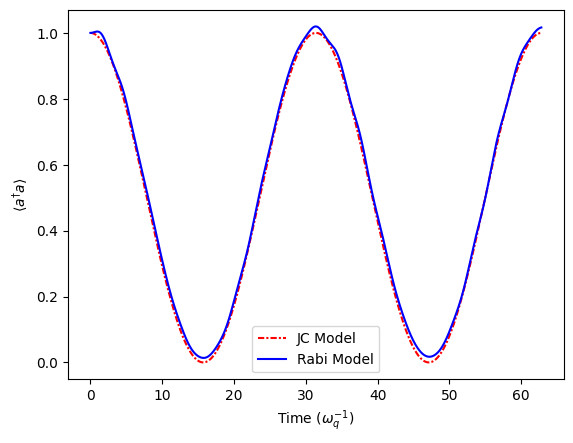

In [20]:
# JC and Rabi model
# plotting photon number vs time for cavDim=5 and stepSize=0.01*pi

cavDimInd = 0
stepSizeInd = 0

ResFid = simulation.qRes.resultsDict

plt.plot(timePoints[stepSizeInd], ResFid['nJC'][cavDimInd][stepSizeInd], linestyle=(0, (3, 1, 1, 1)), color='r', label='JC Model')
plt.plot(timePoints[stepSizeInd], ResFid['nRabi'][cavDimInd][stepSizeInd], linestyle='-', color='b', label='Rabi Model')
plt.legend()

plt.xlabel(r"Time ($\omega_{q}^{-1}$)")
plt.ylabel(r"$\langle a^{\dagger}a \rangle$")

Both digital protocols closely track the photon number dynamics in the Rabi model. The small time step minimizes Trotter error for both order simulations.



Text(0, 0.5, '$\\langle a^{\\dagger}a \\rangle$')

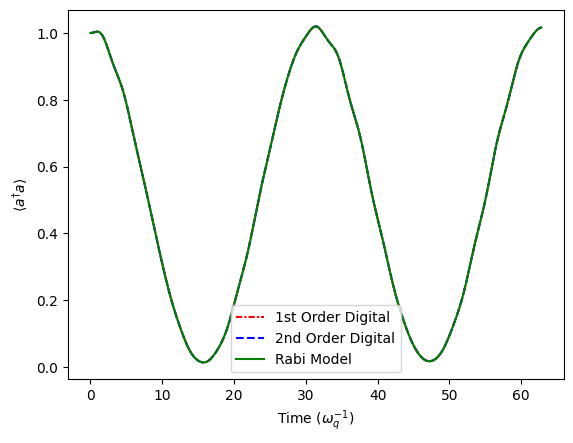

In [11]:
# first and second order digital Rabi and Rabi model
# plotting photon number vs time for cavDim=5 and stepSize=0.01*pi


cavDimInd = 0
stepSizeInd = 0

ResFid = simulation.qRes.resultsDict

plt.plot(timePoints[stepSizeInd], ResFid['nDig1'][cavDimInd][stepSizeInd], linestyle=(0, (3, 1, 1, 1)), color='r', label='1st Order Digital')
plt.plot(timePoints[stepSizeInd], ResFid['nDig2'][cavDimInd][stepSizeInd], linestyle='--', color='b', label='2nd Order Digital')
plt.plot(timePoints[stepSizeInd], ResFid['nRabi'][cavDimInd][stepSizeInd], linestyle='-', color='g', label='Rabi Model')

plt.legend()

plt.xlabel(r"Time ($\omega_{q}^{-1}$)")
plt.ylabel(r"$\langle a^{\dagger}a \rangle$")



Both digital protocols closely track the photon number dynamics in the Rabi model. The small cavity dimension mitigates the error from the large time step for both order simulations.

Text(0, 0.5, '$\\langle a^{\\dagger}a \\rangle$')

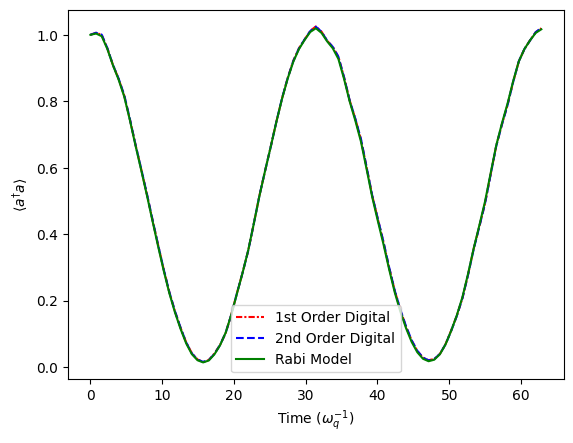

In [12]:
# first and second order digital Rabi and Rabi model
# plotting photon number vs time for cavDim=5 and stepSize=0.25*pi

cavDimInd = 0
stepSizeInd = 1

ResFid = simulation.qRes.resultsDict

plt.plot(timePoints[stepSizeInd], ResFid['nDig1'][cavDimInd][stepSizeInd], linestyle=(0, (3, 1, 1, 1)), color='r', label='1st Order Digital')
plt.plot(timePoints[stepSizeInd], ResFid['nDig2'][cavDimInd][stepSizeInd], linestyle='--', color='b', label='2nd Order Digital')
plt.plot(timePoints[stepSizeInd], ResFid['nRabi'][cavDimInd][stepSizeInd], linestyle='-', color='g', label='Rabi Model')

plt.legend()

plt.xlabel(r"Time ($\omega_{q}^{-1}$)")
plt.ylabel(r"$\langle a^{\dagger}a \rangle$")

Fidelity of second-order digital protocol has significantly better fidelity with the Rabi model than the first-order digital protocol with large step size due to symmetric splitting proving superior error cancellation.

Text(0, 0.5, '$\\mathcal{F}(\\psi_{dig}(t), \\psi_{Rabi}(t))$')

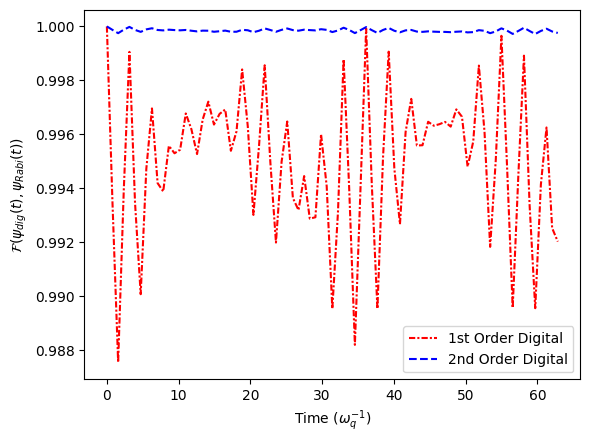

In [13]:
# first and second order digital Rabi model
# plotting fideelity with Rabi model vs time for cavDim=5 and stepSize=0.25*pi

cavDimInd = 0
stepSizeInd = 1
# markEvery = 50

ResFid = simulation.qRes.resultsDict

plt.plot(timePoints[stepSizeInd], ResFid['fidDig1'][cavDimInd][stepSizeInd], linestyle=(0, (3, 1, 1, 1)), color='r', label='1st Order Digital')
plt.plot(timePoints[stepSizeInd], ResFid['fidDig2'][cavDimInd][stepSizeInd], linestyle='--', color='b', label='2nd Order Digital')

plt.legend()

plt.xlabel(r"Time ($\omega_{q}^{-1}$)")
plt.ylabel(r"$\mathcal{F}(\psi_{dig}(t), \psi_{Rabi}(t))$")

Text(0, 0.5, '$\\langle a^{\\dagger}a \\rangle$')

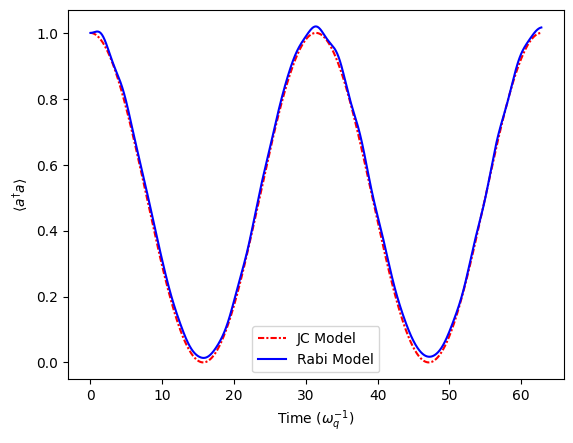

In [21]:
# JC and Rabi model
# plotting photon number vs time for cavDim=100 and stepSize=0.01*pi

cavDimInd = 1
stepSizeInd = 0

ResFid = simulation.qRes.resultsDict

plt.plot(timePoints[stepSizeInd], ResFid['nJC'][cavDimInd][stepSizeInd], linestyle=(0, (3, 1, 1, 1)), color='r', label='JC Model')
plt.plot(timePoints[stepSizeInd], ResFid['nRabi'][cavDimInd][stepSizeInd], linestyle='-', color='b', label='Rabi Model')

plt.legend()

plt.xlabel(r"Time ($\omega_{q}^{-1}$)")
plt.ylabel(r"$\langle a^{\dagger}a \rangle$")

Text(0, 0.5, '$\\langle a^{\\dagger}a \\rangle$')

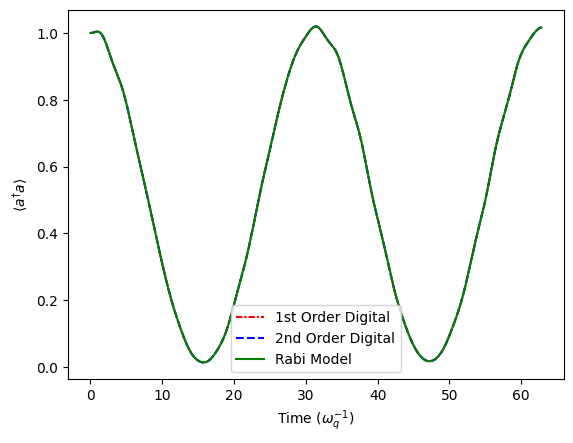

In [16]:
# first and second order digital Rabi and Rabi model
# plotting photon number vs time for cavDim=100 and stepSize=0.01*pi

cavDimInd = 1
stepSizeInd = 0

ResFid = simulation.qRes.resultsDict

plt.plot(timePoints[stepSizeInd], ResFid['nDig1'][cavDimInd][stepSizeInd], linestyle=(0, (3, 1, 1, 1)), color='r', label='1st Order Digital')
plt.plot(timePoints[stepSizeInd], ResFid['nDig2'][cavDimInd][stepSizeInd], linestyle='--', color='b', label='2nd Order Digital')
plt.plot(timePoints[stepSizeInd], ResFid['nRabi'][cavDimInd][stepSizeInd], linestyle='-', color='g', label='Rabi Model')

plt.legend()

plt.xlabel(r"Time ($\omega_{q}^{-1}$)")
plt.ylabel(r"$\langle a^{\dagger}a \rangle$")

Text(0, 0.5, '$\\langle a^{\\dagger}a \\rangle$')

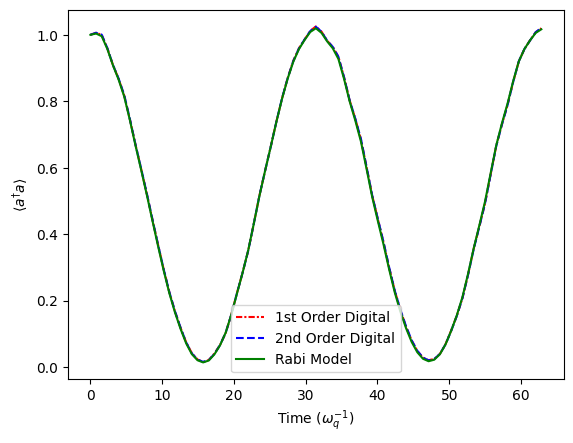

In [17]:
# first and second order digital Rabi and Rabi model
# plotting photon number vs time for cavDim=100 and stepSize=0.25*pi

cavDimInd = 1
stepSizeInd = 1

ResFid = simulation.qRes.resultsDict

plt.plot(timePoints[stepSizeInd], ResFid['nDig1'][cavDimInd][stepSizeInd], linestyle=(0, (3, 1, 1, 1)), color='r', label='1st Order Digital')
plt.plot(timePoints[stepSizeInd], ResFid['nDig2'][cavDimInd][stepSizeInd], linestyle='--', color='b', label='2nd Order Digital')
plt.plot(timePoints[stepSizeInd], ResFid['nRabi'][cavDimInd][stepSizeInd], linestyle='-', color='g', label='Rabi Model')

plt.legend()

plt.xlabel(r"Time ($\omega_{q}^{-1}$)")
plt.ylabel(r"$\langle a^{\dagger}a \rangle$")

Text(0, 0.5, '$\\mathcal{F}(\\psi_{dig}(t), \\psi_{Rabi}(t))$')

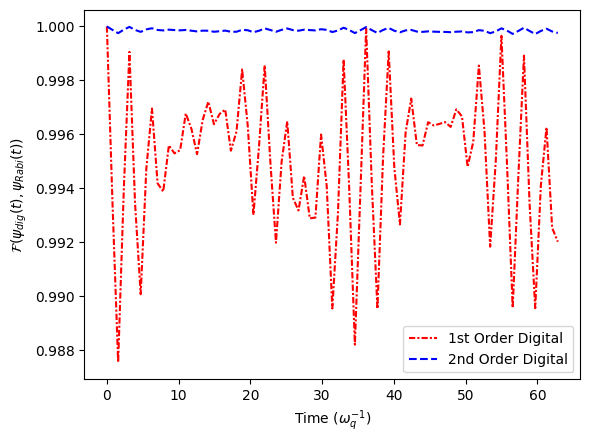

In [18]:
# first and second order digital Rabi and Rabi model
# plotting fideelity with Rabi model vs time for cavDim=100 and stepSize=0.25*pi

cavDimInd = 1
stepSizeInd = 1
# markEvery = 50

ResFid = simulation.qRes.resultsDict

plt.plot(timePoints[stepSizeInd], ResFid['fidDig1'][cavDimInd][stepSizeInd], linestyle=(0, (3, 1, 1, 1)), color='r', label='1st Order Digital')
plt.plot(timePoints[stepSizeInd], ResFid['fidDig2'][cavDimInd][stepSizeInd], linestyle='--', color='b', label='2nd Order Digital')

plt.legend()

plt.xlabel(r"Time ($\omega_{q}^{-1}$)")
plt.ylabel(r"$\mathcal{F}(\psi_{dig}(t), \psi_{Rabi}(t))$")